# Benchmark Training & Evaluation — h24_forecast_weather

Train 3 mô hình benchmark trên dataset `h24_forecast_weather`:
- Features: lag/rolling consumption + **future weather tại t+24h** (future_airTemperature, future_dewTemperature, ...)
- Target: consumption tại t+24h

**Thay đổi so với h24_energy:**
- `DATASET_SUBFOLDER` → `h24_forecast_weather`
- `OUTPUT_BASE` → `output_forecast_weather_24h`
- Không cần loại weather columns — pipeline đã đặt đúng tên `future_*`
- Không cần impute — pipeline đảm bảo 0 null


## 1. Install & Import

In [1]:
!pip install -q polars xgboost lightgbm scikit-learn joblib matplotlib huggingface_hub

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [3]:
import os, gc
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import joblib
import psutil

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb

def ram_usage():
    """In mức RAM hiện tại đang dùng."""
    used = psutil.Process().memory_info().rss / 1024**3
    total = psutil.virtual_memory().total / 1024**3
    print(f'  [RAM] {used:.2f} GB / {total:.2f} GB ({used/total*100:.1f}%)')

print('All imports OK')
ram_usage()

All imports OK
  [RAM] 0.23 GB / 15.79 GB (1.5%)


## 2. Config

In [4]:
# --- Dataset config ---
HF_REPO_ID = "PandaLT/Forecasting-dataset"
DATASET_SUBFOLDER = "h24_forecast_weather"  # ← đổi từ h24_energy

# --- Output dirs ---
OUTPUT_BASE = "D:/dmp-project/result/output_forecast_weather_24h"  # ← đổi
MODELS_DIR = os.path.join(OUTPUT_BASE, "models")
REPORT_DIR = os.path.join(OUTPUT_BASE, "report")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Kiểm tra GPU ---
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    HAS_GPU = result.returncode == 0
except Exception:
    HAS_GPU = False

TREE_DEVICE = 'cuda' if HAS_GPU else 'cpu'
print(f'Output: {OUTPUT_BASE}')
print(f'Dataset: {HF_REPO_ID} / {DATASET_SUBFOLDER}')
print(f'GPU available: {HAS_GPU} → tree models will use: {TREE_DEVICE}')


Output: D:/dmp-project/result/output_forecast_weather_24h
Dataset: PandaLT/Forecasting-dataset / h24_forecast_weather
GPU available: True → tree models will use: cuda


## 3. Load Dataset from Hugging Face

In [6]:
from huggingface_hub import snapshot_download

local_data = snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
)
DATA_DIR = os.path.join(local_data, "dataset", DATASET_SUBFOLDER)
print(f'Downloaded to: {local_data}')
print(f'Data folder: {DATA_DIR}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Downloaded to: /root/.cache/huggingface/hub/datasets--PandaLT--Forecasting-dataset/snapshots/383932eedb32ce04375dbaaa03c93b2e505db25a
Data folder: /root/.cache/huggingface/hub/datasets--PandaLT--Forecasting-dataset/snapshots/383932eedb32ce04375dbaaa03c93b2e505db25a/dataset/h24_energy


In [5]:
train = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/dataset/h24_forecast_weather/train.parquet")
val   = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/dataset/h24_forecast_weather/validation.parquet")
test  = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/dataset/h24_forecast_weather/test.parquet")

print(f'Train:      {train.shape[0]:>10,} rows | {train["timestamp"].min()} → {train["timestamp"].max()}')
print(f'Validation: {val.shape[0]:>10,} rows | {val["timestamp"].min()} → {val["timestamp"].max()}')
print(f'Test:       {test.shape[0]:>10,} rows | {test["timestamp"].min()} → {test["timestamp"].max()}')
print(f'\nFeatures: {train.columns}')
ram_usage()

Train:      17,482,862 rows | 2016-01-08 00:00:00 → 2017-06-30 23:00:00
Validation:  3,087,774 rows | 2017-07-01 00:00:00 → 2017-09-30 23:00:00
Test:        3,024,447 rows | 2017-10-01 00:00:00 → 2017-12-30 23:00:00

Features: ['timestamp', 'building_id', 'consumption', 'site_id', 'primaryspaceusage', 'sqm', 'timezone', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h', 'future_airTemperature', 'future_dewTemperature', 'future_windDirection', 'future_windSpeed', 'target']
  [RAM] 4.41 GB / 15.79 GB (27.9%)


## 4. Prepare Features / Target

> **Tối ưu RAM:** Làm việc hoàn toàn với Polars + numpy, không dùng `.to_pandas()`. Downcast float64 → float32 để tiết kiệm ~50% RAM cho feature matrix.

In [23]:
# ── Step 4: Prepare Features / Target ──────────────────────────────────────
#
# Dataset h24_forecast_weather chứa các cột:
#   - Consumption features: lag_1h, lag_24h, lag_168h, rolling_mean/std 24h/168h
#   - Calendar: hour, day_of_week, month, is_weekend
#   - Future weather: future_airTemperature, future_dewTemperature,
#                     future_precipDepth1HR, future_seaLvlPressure,
#                     future_windDirection, future_windSpeed
#   - Metadata: building_id, primaryspaceusage, sqm, site_id, lat, lng, timezone
#   - consumption (tại t — đã biết khi dự đoán)
#   - target (consumption tại t+24h)
#
# Không cần loại weather columns — pipeline đã đặt đúng tên future_*
# Không cần impute — pipeline đã đảm bảo 0 null trong parquet

# Các cột không mang thông tin hữu ích
USELESS_COLS = {
    "lat", "lng",       # hằng số per building — đã capture qua building_id
    "timezone",         # hằng số per site
    "site_id",          # redundant với building_id
    "consumption"
}

EXCLUDE_COLS = {"target", "timestamp"} | USELESS_COLS

actually_excluded = [c for c in train.columns if c in EXCLUDE_COLS]
print(f'Excluded ({len(actually_excluded)}): {actually_excluded}')

FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE_COLS]

# Tự động detect categorical cols
CATEGORICAL_COLS = [
    c for c in FEATURE_COLS
    if train[c].dtype in (pl.String, pl.Utf8, pl.Categorical)
]
NUMERIC_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

# Liệt kê future weather cols đang có
future_wx_cols = [c for c in FEATURE_COLS if c.startswith("future_")]
print(f'\nFuture weather features ({len(future_wx_cols)}): {future_wx_cols}')
print(f'Total features: {len(FEATURE_COLS)}')
print(f'Categorical: {CATEGORICAL_COLS}')

# ── Helper functions ────────────────────────────────────────────────────────

def downcast_floats(df: pl.DataFrame) -> pl.DataFrame:
    cast_exprs = [
        pl.col(c).cast(pl.Float32) if df[c].dtype == pl.Float64 else pl.col(c)
        for c in df.columns
    ]
    return df.select(cast_exprs)


def encode_and_process(train_df, val_df, test_df, cat_cols, feature_cols):
    needed = feature_cols + ["target"]

    vocab = {}
    for col in cat_cols:
        unique_vals = sorted(
            str(v) for v in train_df[col].drop_nulls().unique().to_list()
        )
        vocab[col] = {v: idx for idx, v in enumerate(unique_vals)}

    def encode_df(df):
        df = df.select(needed)
        encode_exprs = []
        for col in df.columns:
            if col in vocab:
                mapping = vocab[col]
                encode_exprs.append(
                    pl.col(col)
                    .cast(pl.String)
                    .map_elements(lambda x, m=mapping: m.get(x, -1), return_dtype=pl.Int32)
                    .cast(pl.Float32)
                    .alias(col)
                )
            else:
                encode_exprs.append(pl.col(col))
        df = df.select(encode_exprs)
        return downcast_floats(df)

    return encode_df(train_df), encode_df(val_df), encode_df(test_df)


# ── Null check — pipeline đảm bảo 0 null, nhưng verify để chắc chắn ─────────
for split_name, split_df in [("train", train), ("val", val), ("test", test)]:
    null_counts = split_df.select([
        pl.col(c).is_null().sum().alias(c) for c in split_df.columns
    ])
    total_nulls = sum(null_counts.row(0))
    if total_nulls > 0:
        bad = {c: null_counts[c][0] for c in split_df.columns if null_counts[c][0] > 0}
        raise RuntimeError(f"[{split_name}] Dataset có null — cần re-run pipeline: {bad}")
print("Null check passed — 0 nulls in all splits.")

# ── Load → Encode → Free ────────────────────────────────────────────────────
needed_cols = FEATURE_COLS + ["target"]

train_slim, val_slim, test_slim = encode_and_process(
    train.select(needed_cols),
    val.select(needed_cols),
    test.select(needed_cols),
    CATEGORICAL_COLS,
    FEATURE_COLS,
)

del train, val, test
gc.collect()
print('Freed original dataframes')
ram_usage()

# ── Extract numpy ────────────────────────────────────────────────────────────
remaining_str = [c for c in FEATURE_COLS if train_slim[c].dtype == pl.String]
if remaining_str:
    raise RuntimeError(f"Vẫn còn string columns chưa encode: {remaining_str}")

X_train = train_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_train = train_slim["target"].to_numpy()

X_val   = val_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_val   = val_slim["target"].to_numpy()

X_test  = test_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_test  = test_slim["target"].to_numpy()

del train_slim, val_slim, test_slim
gc.collect()

print(f'X_train: {X_train.shape}, dtype={X_train.dtype}  ({X_train.nbytes/1024**3:.2f} GB)')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
ram_usage()


Excluded (5): ['timestamp', 'consumption', 'site_id', 'timezone', 'target']

Future weather features (4): ['future_airTemperature', 'future_dewTemperature', 'future_windDirection', 'future_windSpeed']
Total features: 18
Categorical: ['building_id', 'primaryspaceusage']
Null check passed — 0 nulls in all splits.
Freed original dataframes
  [RAM] 5.03 GB / 15.79 GB (31.8%)
X_train: (17482862, 18), dtype=float32  (1.17 GB)
X_val:   (3087774, 18)
X_test:  (3024447, 18)
  [RAM] 6.56 GB / 15.79 GB (41.5%)


## 5. Train Models


> - **XGBoost/LightGBM:** dùng `device='cuda'` nếu có T4, training data nằm trên GPU VRAM thay vì RAM
> - Mỗi model được `gc.collect()` sau khi fit xong

In [11]:
# Cell này không cần thiết cho h24_forecast_weather
# Pipeline đã đảm bảo 0 null — null check đã được tích hợp vào cell 12
# (Cell giữ lại để không làm lệch số thứ tự các cell)


In [32]:
xgb_params = dict(
    objective="reg:absoluteerror",
    
    n_estimators=1000,
    early_stopping_rounds=200,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1 if TREE_DEVICE == 'cpu' else 1,
    tree_method='hist',
    device=TREE_DEVICE,
)

models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(**xgb_params)
}

trained = {}

for name, model in models.items():
    print(f'\n[{name}] Training...')
    ram_usage()

    if name in ("XGBoost", "LightGBM"):
        if name == "LightGBM":
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=100),
                ],
            )
        else:
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=100,
            )
    else:
        model.fit(X_train, y_train)

    trained[name] = model
    gc.collect()
    print(f'  ✓ Done: {name}')
    ram_usage()


[Linear Regression] Training...
  [RAM] 1.57 GB / 15.79 GB (9.9%)
  ✓ Done: Linear Regression
  [RAM] 1.61 GB / 15.79 GB (10.2%)

[XGBoost] Training...
  [RAM] 1.61 GB / 15.79 GB (10.2%)
[0]	validation_0-mae:120.51860
[100]	validation_0-mae:16.15012
[200]	validation_0-mae:14.67911
[300]	validation_0-mae:14.21921
[400]	validation_0-mae:13.91177
[500]	validation_0-mae:13.61777
[600]	validation_0-mae:13.40467
[700]	validation_0-mae:13.18704
[800]	validation_0-mae:13.01939
[900]	validation_0-mae:12.87569
[999]	validation_0-mae:12.73258
  ✓ Done: XGBoost
  [RAM] 1.82 GB / 15.79 GB (11.5%)


## 6. Evaluate

In [37]:
def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, MAPE, SMAPE. MAPE dùng mask y_true > 1 để tránh nổ."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE chỉ tính trên target > 1 để tránh chia cho 0 hoặc giá trị gần 0 (review #3)
    mask = y_true > 1
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = float('nan')
    smape = (
        2 * np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    )
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape}


rows = []
for name, model in trained.items():
    y_val_pred  = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_metrics  = calculate_metrics(y_val, y_val_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    row = {"Model": name}
    for k, v in val_metrics.items():
        row[f"Val_{k}"] = round(v, 4)
    for k, v in test_metrics.items():
        row[f"Test_{k}"] = round(v, 4)
    rows.append(row)

leaderboard = pl.DataFrame(rows)
print(leaderboard)

shape: (2, 9)
┌──────────────┬─────────┬──────────┬──────────┬───┬──────────┬───────────┬───────────┬────────────┐
│ Model        ┆ Val_MAE ┆ Val_RMSE ┆ Val_MAPE ┆ … ┆ Test_MAE ┆ Test_RMSE ┆ Test_MAPE ┆ Test_SMAPE │
│ ---          ┆ ---     ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---       ┆ ---       ┆ ---        │
│ str          ┆ f64     ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64       ┆ f64       ┆ f64        │
╞══════════════╪═════════╪══════════╪══════════╪═══╪══════════╪═══════════╪═══════════╪════════════╡
│ Linear       ┆ 17.325  ┆ 59.3536  ┆ 31.2679  ┆ … ┆ 15.2446  ┆ 37.8653   ┆ 28.6151   ┆ 36.0895    │
│ Regression   ┆         ┆          ┆          ┆   ┆          ┆           ┆           ┆            │
│ XGBoost      ┆ 12.7326 ┆ 47.0496  ┆ 15.5275  ┆ … ┆ 11.3688  ┆ 35.0126   ┆ 14.4203   ┆ 21.572701  │
└──────────────┴─────────┴──────────┴──────────┴───┴──────────┴───────────┴───────────┴────────────┘


In [34]:
leaderboard.write_csv(os.path.join(REPORT_DIR, "model_leaderboard.csv"))
print(f'Saved leaderboard.')

Saved leaderboard.


## 7. Actual vs Predicted Plot

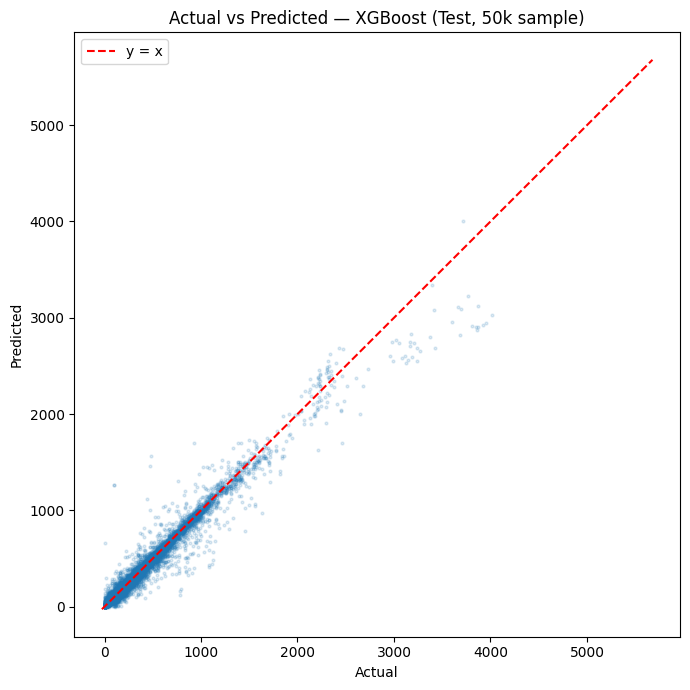

Saved: D:/dmp-project/result/output_forecast_weather_24h\report\actual_vs_predicted.png


In [35]:
# Chọn best model theo MAE thay vì RMSE (review #2)
best_name  = leaderboard.sort("Test_MAPE")["Model"][0]
best_model = trained[best_name]
y_pred     = best_model.predict(X_test)

# Sample 50k điểm để plot nhanh (17M điểm làm scatter rất chậm)
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), size=min(50_000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test[idx], y_pred[idx], alpha=0.15, s=4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"Actual vs Predicted — {best_name} (Test, 50k sample)")
ax.legend()
plt.tight_layout()
plot_path = os.path.join(REPORT_DIR, "actual_vs_predicted.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Saved: {plot_path}')

## 8. Feature Importance

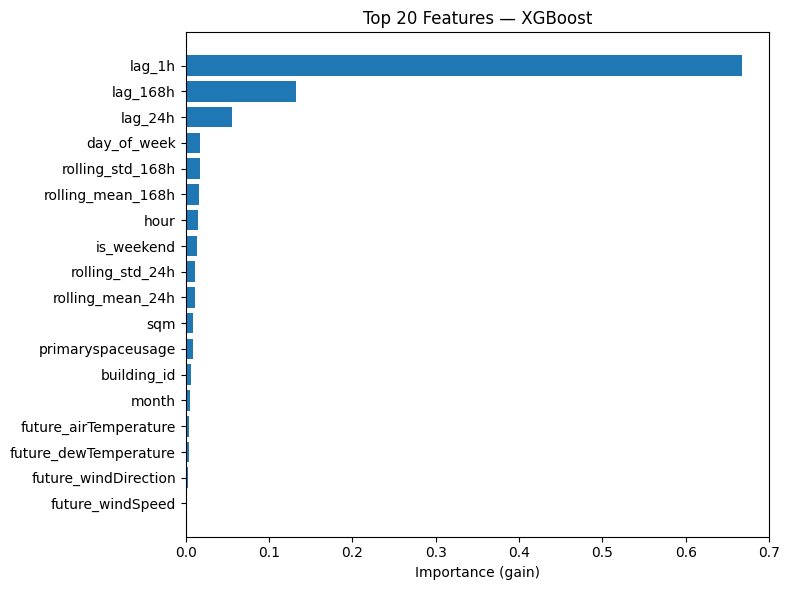

Saved: D:/dmp-project/result/output_forecast_weather_24h\report\feature_importance.png


In [38]:
tree_model = best_model

if hasattr(tree_model, "get_booster"):
    # XGBoost: dùng gain thay vì weight (default của feature_importances_)
    score = tree_model.get_booster().get_score(importance_type="gain")
    # Normalize về [0,1]
    total = sum(score.values()) or 1
    importances = np.array([
        score.get(f"f{i}", 0) / total for i in range(len(FEATURE_COLS))
    ])
elif hasattr(tree_model, "feature_importances_"):
    # LightGBM, RandomForest
    importances = tree_model.feature_importances_
else:
    importances = None

if importances is not None:
    top_k = 20
    idx = np.argsort(importances)[-top_k:]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([FEATURE_COLS[i] for i in idx], importances[idx])
    ax.set_xlabel("Importance (gain)")
    ax.set_title(f"Top {top_k} Features — {best_name}")
    plt.tight_layout()
    fi_path = os.path.join(REPORT_DIR, "feature_importance.png")
    plt.savefig(fi_path, dpi=120)
    plt.show()
    print(f"Saved: {fi_path}")
else:
    print(f"{best_name} does not expose feature importances.")

## 9. Save Artifacts

In [ ]:
for name, model in trained.items():
    safe_name = name.lower().replace(" ", "_")
    path = os.path.join(MODELS_DIR, f"{safe_name}.pkl")
    joblib.dump(model, path)
    print(f'Saved: {path}')

best_path = os.path.join(MODELS_DIR, "best_model.pkl")
joblib.dump(best_model, best_path)
print(f'\nBest model ({best_name}): {best_path}')

In [ ]:
!pip install tabulate

In [ ]:
lb_pd = leaderboard.to_pandas()

summary_lines = [
    "# Evaluation Summary",
    f"Dataset: {DATASET_SUBFOLDER}",
    "",
    "## Leaderboard",
    lb_pd.to_markdown(index=False),
    "",
    "## Best Model",
    best_name,
]

summary_path = os.path.join(REPORT_DIR, "evaluation_summary.md")
with open(summary_path, "w") as f:
    f.write("\n".join(summary_lines))
print(f'Saved: {summary_path}')

Saved: /content/output_energy_24h/report/evaluation_summary.md


In [6]:
sample = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/dataset/h24_forecast_weather/train.parquet").sort(["building_id", "timestamp"])

# Lấy 1 building, in vài dòng liên tiếp
bid = sample["building_id"][0]
check = sample.filter(pl.col("building_id") == bid).select([
    "timestamp", "consumption", "future_airTemperature"
]).head(10)
print(check)

shape: (10, 3)
┌─────────────────────┬─────────────┬───────────────────────┐
│ timestamp           ┆ consumption ┆ future_airTemperature │
│ ---                 ┆ ---         ┆ ---                   │
│ datetime[μs]        ┆ f64         ┆ f64                   │
╞═════════════════════╪═════════════╪═══════════════════════╡
│ 2016-01-08 00:00:00 ┆ 231.8       ┆ 10.6                  │
│ 2016-01-08 01:00:00 ┆ 217.65      ┆ 10.0                  │
│ 2016-01-08 02:00:00 ┆ 215.55      ┆ 10.6                  │
│ 2016-01-08 03:00:00 ┆ 215.25      ┆ 10.0                  │
│ 2016-01-08 04:00:00 ┆ 219.7       ┆ 10.0                  │
│ 2016-01-08 05:00:00 ┆ 332.85      ┆ 10.0                  │
│ 2016-01-08 06:00:00 ┆ 384.45      ┆ 10.0                  │
│ 2016-01-08 07:00:00 ┆ 676.2       ┆ 9.4                   │
│ 2016-01-08 08:00:00 ┆ 686.4       ┆ 10.0                  │
│ 2016-01-08 09:00:00 ┆ 704.9       ┆ 10.6                  │
└─────────────────────┴─────────────┴──────────────────

In [7]:
bid = sample["building_id"][0]
check = sample.filter(pl.col("building_id") == bid).select([
    "timestamp", "consumption", "future_airTemperature"
]).head(10)
print(check)

shape: (10, 3)
┌─────────────────────┬─────────────┬───────────────────────┐
│ timestamp           ┆ consumption ┆ future_airTemperature │
│ ---                 ┆ ---         ┆ ---                   │
│ datetime[μs]        ┆ f64         ┆ f64                   │
╞═════════════════════╪═════════════╪═══════════════════════╡
│ 2016-01-08 00:00:00 ┆ 231.8       ┆ 10.6                  │
│ 2016-01-08 01:00:00 ┆ 217.65      ┆ 10.0                  │
│ 2016-01-08 02:00:00 ┆ 215.55      ┆ 10.6                  │
│ 2016-01-08 03:00:00 ┆ 215.25      ┆ 10.0                  │
│ 2016-01-08 04:00:00 ┆ 219.7       ┆ 10.0                  │
│ 2016-01-08 05:00:00 ┆ 332.85      ┆ 10.0                  │
│ 2016-01-08 06:00:00 ┆ 384.45      ┆ 10.0                  │
│ 2016-01-08 07:00:00 ┆ 676.2       ┆ 9.4                   │
│ 2016-01-08 08:00:00 ┆ 686.4       ┆ 10.0                  │
│ 2016-01-08 09:00:00 ┆ 704.9       ┆ 10.6                  │
└─────────────────────┴─────────────┴──────────────────

In [8]:
gold = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/gold/validated_v2_h24_forecast.parquet")
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
bid = train["building_id"][0]  # hoặc lấy cùng building_id như trên

# Lấy airTemperature gốc từ Gold, ngày 08 và 09/01
gold_check = (
    gold
    .filter(
        (pl.col("building_id") == bid) &
        (pl.col("timestamp") >= pl.lit("2016-01-08 00:00:00").str.to_datetime()) &
        (pl.col("timestamp") <= pl.lit("2016-01-09 09:00:00").str.to_datetime())
    )
    .select(["timestamp", "airTemperature"])
    .sort("timestamp")
)
print(gold_check)

shape: (34, 2)
┌─────────────────────┬────────────────┐
│ timestamp           ┆ airTemperature │
│ ---                 ┆ ---            │
│ datetime[μs]        ┆ f64            │
╞═════════════════════╪════════════════╡
│ 2016-01-08 00:00:00 ┆ 6.1            │
│ 2016-01-08 01:00:00 ┆ 6.1            │
│ 2016-01-08 02:00:00 ┆ 6.1            │
│ 2016-01-08 03:00:00 ┆ 6.1            │
│ 2016-01-08 04:00:00 ┆ 6.1            │
│ 2016-01-08 05:00:00 ┆ 7.2            │
│ 2016-01-08 06:00:00 ┆ 6.7            │
│ 2016-01-08 07:00:00 ┆ 7.2            │
│ 2016-01-08 08:00:00 ┆ 7.8            │
│ 2016-01-08 09:00:00 ┆ 8.9            │
│ 2016-01-08 10:00:00 ┆ 10.0           │
│ 2016-01-08 11:00:00 ┆ 10.0           │
│ 2016-01-08 12:00:00 ┆ 10.0           │
│ 2016-01-08 13:00:00 ┆ 10.6           │
│ 2016-01-08 14:00:00 ┆ 11.7           │
│ 2016-01-08 15:00:00 ┆ 10.6           │
│ 2016-01-08 16:00:00 ┆ 11.1           │
│ 2016-01-08 17:00:00 ┆ 10.6           │
│ 2016-01-08 18:00:00 ┆ 10.0           │
│

In [9]:
# Xem phân phối future_airTemperature trong toàn bộ train set
train_raw = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/dataset/h24_forecast_weather/train.parquet")

print(train_raw.select([
    pl.col("future_airTemperature").min().alias("min"),
    pl.col("future_airTemperature").max().alias("max"),
    pl.col("future_airTemperature").mean().alias("mean"),
    pl.col("future_airTemperature").std().alias("std"),
]))

# Và correlation với target
print(train_raw.select([
    pl.corr("future_airTemperature", "target", method="pearson").alias("corr_airTemp_target"),
    pl.corr("future_dewTemperature", "target", method="pearson").alias("corr_dewTemp_target"),
    pl.corr("lag_1h", "target", method="pearson").alias("corr_lag1h_target"),
]))

shape: (1, 4)
┌───────┬──────┬───────────┬───────────┐
│ min   ┆ max  ┆ mean      ┆ std       │
│ ---   ┆ ---  ┆ ---       ┆ ---       │
│ f64   ┆ f64  ┆ f64       ┆ f64       │
╞═══════╪══════╪═══════════╪═══════════╡
│ -28.9 ┆ 48.3 ┆ 15.274622 ┆ 10.239095 │
└───────┴──────┴───────────┴───────────┘
shape: (1, 3)
┌─────────────────────┬─────────────────────┬───────────────────┐
│ corr_airTemp_target ┆ corr_dewTemp_target ┆ corr_lag1h_target │
│ ---                 ┆ ---                 ┆ ---               │
│ f64                 ┆ f64                 ┆ f64               │
╞═════════════════════╪═════════════════════╪═══════════════════╡
│ 0.007208            ┆ -0.027691           ┆ 0.977729          │
└─────────────────────┴─────────────────────┴───────────────────┘


In [11]:
corr_by_type = (
    train_raw
    .group_by("primaryspaceusage")
    .agg([
        pl.corr("future_airTemperature", "target", method="pearson").alias("corr_airTemp"),
        pl.len().alias("n_rows"),
    ])
    .sort("corr_airTemp", descending=True)
)
print(corr_by_type)

shape: (16, 3)
┌───────────────────────────────┬──────────────┬─────────┐
│ primaryspaceusage             ┆ corr_airTemp ┆ n_rows  │
│ ---                           ┆ ---          ┆ ---     │
│ str                           ┆ f64          ┆ u32     │
╞═══════════════════════════════╪══════════════╪═════════╡
│ Utility                       ┆ 0.354819     ┆ 46764   │
│ Retail                        ┆ 0.241372     ┆ 113827  │
│ Services                      ┆ 0.117222     ┆ 112252  │
│ Entertainment/public assembly ┆ 0.077263     ┆ 2156001 │
│ Healthcare                    ┆ 0.037362     ┆ 315759  │
│ Other                         ┆ 0.032491     ┆ 286423  │
│ Lodging/residential           ┆ 0.029045     ┆ 1716534 │
│ Warehouse/storage             ┆ 0.027314     ┆ 159913  │
│ Education                     ┆ 0.022783     ┆ 6797268 │
│ Office                        ┆ -0.001972    ┆ 3294451 │
│ Public services               ┆ -0.029297    ┆ 1932170 │
│ Manufacturing/industrial      ┆ -0.0373

In [12]:
import polars as pl

# Hoặc đọc trực tiếp bronze weather
# Nếu có report file:
try:
    report = pl.read_csv("D:/dmp-project/data2/processed/forecasting/report/bronze_weather_null_summary.csv")
    print("Bronze weather null rates:")
    print(report)
except:
    print("Report file not found")

# 2. Đếm số giá trị bị trùng lặp trong Gold weather
gold = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/gold/validated_v2_h24_forecast.parquet")

# Lấy weather per site (unique timestamp × site_id)
weather = gold.select(["timestamp", "site_id", "airTemperature"]).unique(
    subset=["timestamp", "site_id"]
).sort(["site_id", "timestamp"])

# Đếm % giá trị giống hệt giờ trước
weather = weather.with_columns(
    (pl.col("airTemperature") == pl.col("airTemperature").shift(1).over("site_id"))
    .alias("same_as_prev")
)

pct_same = weather.select(pl.col("same_as_prev").mean()).item()
print(f"\n% giờ có airTemperature giống hệt giờ trước: {pct_same:.1%}")

# 3. Check per site — site nào bị nặng nhất
per_site = (
    weather.group_by("site_id")
    .agg([
        pl.col("same_as_prev").mean().alias("pct_same"),
        pl.col("airTemperature").n_unique().alias("n_unique_values"),
        pl.len().alias("n_rows"),
    ])
    .sort("pct_same", descending=True)
)
print("\nPer-site repetition rate:")
print(per_site)

Bronze weather null rates:
shape: (6, 2)
┌────────────────┬───────────┐
│ column         ┆ null_rate │
│ ---            ┆ ---       │
│ str            ┆ f64       │
╞════════════════╪═══════════╡
│ timestamp      ┆ 0.0       │
│ site_id        ┆ 0.0       │
│ airTemperature ┆ 0.000387  │
│ dewTemperature ┆ 0.00099   │
│ windDirection  ┆ 0.03927   │
│ windSpeed      ┆ 0.001733  │
└────────────────┴───────────┘

% giờ có airTemperature giống hệt giờ trước: 20.4%

Per-site repetition rate:
shape: (17, 4)
┌──────────┬──────────┬─────────────────┬────────┐
│ site_id  ┆ pct_same ┆ n_unique_values ┆ n_rows │
│ ---      ┆ ---      ┆ ---             ┆ ---    │
│ str      ┆ f64      ┆ u32             ┆ u32    │
╞══════════╪══════════╪═════════════════╪════════╡
│ Lamb     ┆ 0.534002 ┆ 57              ┆ 17544  │
│ Hog      ┆ 0.286496 ┆ 123             ┆ 17544  │
│ Bear     ┆ 0.268141 ┆ 70              ┆ 17544  │
│ Rat      ┆ 0.266032 ┆ 102             ┆ 17544  │
│ Cockatoo ┆ 0.259135 ┆ 312       

In [17]:
import polars as pl
import numpy as np

# ═══════════════════════════════════════════════════════════════
# Đường dẫn — sửa lại cho đúng máy bạn
# ═══════════════════════════════════════════════════════════════
BRONZE_ELEC   = "D:/dmp-project/data2/processed/forecasting/bronze/electricity.parquet"      # hoặc đường dẫn bronze
BRONZE_WEATHER= "D:/dmp-project/data2/processed/forecasting/bronze/weather.parquet"
BRONZE_META   = "D:/dmp-project/data2/processed/forecasting/bronze/metadata.parquet"
SILVER_PATH   = "D:/dmp-project/data2/processed/forecasting/silver/merged.parquet"
GOLD_V2_PATH  = "D:/dmp-project/data2/processed/forecasting/gold/validated_v2_h24_forecast.parquet"
TRAIN_PATH    = "D:/dmp-project/data2/processed/forecasting/dataset/h24_forecast_weather/train.parquet"


def corr_by_site(df: pl.DataFrame, temp_col: str, target_col: str) -> pl.DataFrame:
    """Tính correlation weather vs consumption per site_id."""
    return (
        df.filter(
            pl.col(temp_col).is_not_null() & pl.col(target_col).is_not_null()
        )
        .group_by("site_id")
        .agg([
            pl.corr(temp_col, target_col).alias("correlation"),
            pl.col(temp_col).std().alias("temp_std"),
            pl.col(temp_col).n_unique().alias("temp_unique"),
            pl.col(target_col).std().alias("target_std"),
            pl.len().alias("n_rows"),
        ])
        .sort("site_id")
    )


# ═══════════════════════════════════════════════════════════════
# Stage 1: BRONZE — raw data, trước mọi xử lý
# ═══════════════════════════════════════════════════════════════
print("=" * 60)
print("STAGE 1: BRONZE (raw)")
print("=" * 60)

elec = pl.read_parquet(BRONZE_ELEC)
weather = pl.read_parquet(BRONZE_WEATHER)
meta = pl.read_parquet(BRONZE_META)

# Join: elec → meta (lấy site_id) → weather (lấy airTemperature)
bronze_joined = (
    elec
    .join(meta.select(["building_id", "site_id"]), on="building_id", how="left")
    .join(weather.select(["timestamp", "site_id", "airTemperature"]),
          on=["timestamp", "site_id"], how="left")
)

print(f"Rows: {bronze_joined.shape[0]:,}")
print(f"airTemperature null: {bronze_joined['airTemperature'].is_null().mean():.2%}")
print(f"\nCorrelation by site_id (BRONZE):")
bronze_corr = corr_by_site(bronze_joined, "airTemperature", "consumption")
print(bronze_corr)

# Global correlation
global_corr = bronze_joined.select(
    pl.corr("airTemperature", "consumption",method="pearson")
).item()
print(f"\nGlobal correlation (BRONZE): {global_corr:.6f}")

del bronze_joined, elec, weather, meta
import gc; gc.collect()


# ═══════════════════════════════════════════════════════════════
# Stage 2: SILVER — sau preprocessing (align + interpolation + merge)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STAGE 2: SILVER (after preprocessing)")
print("=" * 60)

silver = pl.read_parquet(SILVER_PATH)
print(f"Rows: {silver.shape[0]:,}")
print(f"airTemperature null: {silver['airTemperature'].is_null().mean():.2%}")

print(f"\nCorrelation by site_id (SILVER):")
silver_corr = corr_by_site(silver, "airTemperature", "consumption")
print(silver_corr)

global_corr = silver.select(
    pl.corr("airTemperature", "consumption",method="pearson")
).item()
print(f"\nGlobal correlation (SILVER): {global_corr:.6f}")

del silver; gc.collect()


# ═══════════════════════════════════════════════════════════════
# Stage 3: GOLD V2 — sau outlier detection + re-handling
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STAGE 3: GOLD V2 (after outlier)")
print("=" * 60)

gold = pl.read_parquet(GOLD_V2_PATH)
print(f"Rows: {gold.shape[0]:,}")
print(f"airTemperature null: {gold['airTemperature'].is_null().mean():.2%}")

print(f"\nCorrelation by site_id (GOLD V2):")
gold_corr = corr_by_site(gold, "airTemperature", "consumption")
print(gold_corr)

global_corr = gold.select(
    pl.corr("airTemperature", "consumption",method="pearson")
).item()
print(f"\nGlobal correlation (GOLD V2): {global_corr:.6f}")

del gold; gc.collect()


# ═══════════════════════════════════════════════════════════════
# Stage 4: TRAIN — sau feature engineering (future_airTemperature vs target)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STAGE 4: TRAIN (feature store — future weather vs target)")
print("=" * 60)

train = pl.read_parquet(TRAIN_PATH)
print(f"Rows: {train.shape[0]:,}")

# Ở đây weather đã bị shift thành future_airTemperature, target = consumption(t+24)
print(f"\nCorrelation by site_id (TRAIN — future_airTemp vs target):")
train_corr = corr_by_site(train, "future_airTemperature", "target")
print(train_corr)

global_corr = train.select(
    pl.corr("future_airTemperature", "target")
).item()
print(f"\nGlobal correlation (TRAIN): {global_corr:.6f}")


# ═══════════════════════════════════════════════════════════════
# So sánh tổng hợp qua các stage
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SUMMARY — Correlation thay đổi qua từng stage")
print("=" * 60)

summary = bronze_corr.select([
    "site_id",
    pl.col("correlation").alias("bronze"),
    pl.col("temp_std").alias("bronze_temp_std"),
    pl.col("temp_unique").alias("bronze_temp_unique"),
]).join(
    silver_corr.select(["site_id", pl.col("correlation").alias("silver"),
                         pl.col("temp_std").alias("silver_temp_std")]),
    on="site_id", how="left"
).join(
    gold_corr.select(["site_id", pl.col("correlation").alias("gold_v2"),
                        pl.col("temp_std").alias("gold_temp_std")]),
    on="site_id", how="left"
).join(
    train_corr.select(["site_id", pl.col("correlation").alias("train"),
                         pl.col("temp_std").alias("train_temp_std")]),
    on="site_id", how="left"
)

print(summary)

STAGE 1: BRONZE (raw)
Rows: 27,684,432
airTemperature null: 0.38%

Correlation by site_id (BRONZE):
shape: (19, 6)
┌──────────┬─────────────┬───────────┬─────────────┬────────────┬─────────┐
│ site_id  ┆ correlation ┆ temp_std  ┆ temp_unique ┆ target_std ┆ n_rows  │
│ ---      ┆ ---         ┆ ---       ┆ ---         ┆ ---        ┆ ---     │
│ str      ┆ f64         ┆ f64       ┆ u32         ┆ f64        ┆ u32     │
╞══════════╪═════════════╪═══════════╪═════════════╪════════════╪═════════╡
│ Bear     ┆ 0.05613     ┆ 4.328171  ┆ 68          ┆ 284.933201 ┆ 1546784 │
│ Bobcat   ┆ 0.012111    ┆ 11.10077  ┆ 97          ┆ 86.189675  ┆ 438148  │
│ Bull     ┆ 0.026981    ┆ 7.978225  ┆ 88          ┆ 326.826592 ┆ 2075770 │
│ Cockatoo ┆ 0.014162    ┆ 10.504962 ┆ 139         ┆ 178.234282 ┆ 1764821 │
│ Crow     ┆ 0.3454      ┆ 11.745804 ┆ 591         ┆ 138.208173 ┆ 78774   │
│ Eagle    ┆ 0.014682    ┆ 10.087649 ┆ 95          ┆ 236.407506 ┆ 1726379 │
│ Fox      ┆ 0.027252    ┆ 9.144323  ┆ 97        

Total buildings: 1433

Correlation stats:
shape: (1, 7)
┌───────────┬───────────┬──────────┬─────────┬──────────┬──────────┬─────────┐
│ min       ┆ Q1        ┆ median   ┆ mean    ┆ Q3       ┆ max      ┆ std     │
│ ---       ┆ ---       ┆ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---     │
│ f64       ┆ f64       ┆ f64      ┆ f64     ┆ f64      ┆ f64      ┆ f64     │
╞═══════════╪═══════════╪══════════╪═════════╪══════════╪══════════╪═════════╡
│ -0.916233 ┆ -0.043687 ┆ 0.138458 ┆ 0.15036 ┆ 0.368521 ┆ 0.868872 ┆ 0.32166 │
└───────────┴───────────┴──────────┴─────────┴──────────┴──────────┴─────────┘

═══ Top 20 POSITIVE correlation ═══
shape: (20, 7)
┌────────────────┬─────────┬────────────────┬─────────────┬───────────────┬───────────────┬────────┐
│ building_id    ┆ site_id ┆ primaryspaceus ┆ correlation ┆ mean_consumpt ┆ std_consumpti ┆ n_rows │
│ ---            ┆ ---     ┆ age            ┆ ---         ┆ ion           ┆ on            ┆ ---    │
│ str            ┆ str     ┆ ---    

C:\Users\Admin.ADMIN-PC\AppData\Local\Temp\ipykernel_4340\2847153238.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=sites_sorted, vert=False, patch_artist=True,


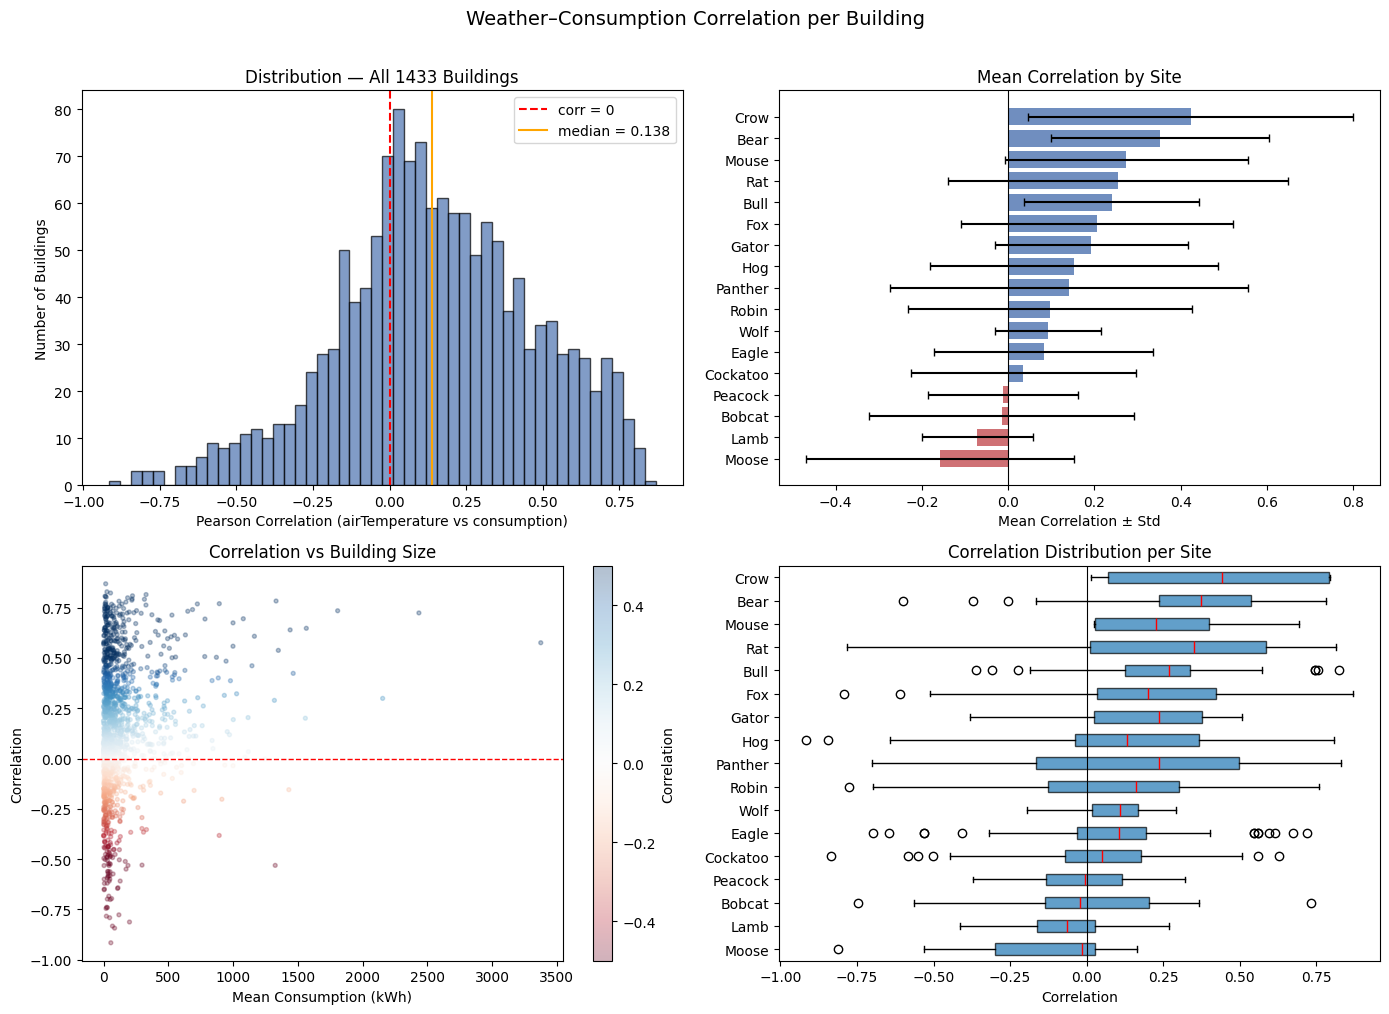


═══ Summary ═══
Total buildings: 1433
|corr| > 0.3 (strong):   574 (40.1%)
  positive > 0.3:        463
  negative < -0.3:       111
|corr| > 0.15 (moderate): 932 (65.0%)
|corr| ≤ 0.15 (weak):    501 (35.0%)


In [19]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

gold = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/gold/validated_v2_h24_forecast.parquet")

corr_by_building = (
    gold
    .filter(
        pl.col("airTemperature").is_not_null() & pl.col("consumption").is_not_null()
    )
    .group_by(["building_id", "site_id", "primaryspaceusage"])
    .agg([
        pl.corr("airTemperature", "consumption", method="pearson").alias("correlation"),
        pl.col("consumption").mean().alias("mean_consumption"),
        pl.col("consumption").std().alias("std_consumption"),
        pl.len().alias("n_rows"),
    ])
    .filter(pl.col("n_rows") > 100)
    .sort("correlation", descending=True)
)

print(f"Total buildings: {corr_by_building.shape[0]}")
print(f"\nCorrelation stats:")
print(corr_by_building.select([
    pl.col("correlation").min().alias("min"),
    pl.col("correlation").quantile(0.25).alias("Q1"),
    pl.col("correlation").median().alias("median"),
    pl.col("correlation").mean().alias("mean"),
    pl.col("correlation").quantile(0.75).alias("Q3"),
    pl.col("correlation").max().alias("max"),
    pl.col("correlation").std().alias("std"),
]))

print("\n═══ Top 20 POSITIVE correlation ═══")
print(corr_by_building.head(20))

print("\n═══ Top 20 NEGATIVE correlation ═══")
print(corr_by_building.tail(20))

avg_by_site = (
    corr_by_building
    .group_by("site_id")
    .agg([
        pl.col("correlation").mean().alias("mean_corr"),
        pl.col("correlation").std().alias("std_corr"),
        pl.col("correlation").min().alias("min_corr"),
        pl.col("correlation").max().alias("max_corr"),
        pl.len().alias("n_buildings"),
    ])
    .sort("mean_corr", descending=True)
)
print("\n═══ Average correlation by site_id ═══")
print(avg_by_site)

corr_values = corr_by_building["correlation"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(corr_values, bins=50, edgecolor="black", alpha=0.7, color="#4C72B0")
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="corr = 0")
ax.axvline(x=np.median(corr_values), color="orange", linestyle="-", linewidth=1.5,
           label=f"median = {np.median(corr_values):.3f}")
ax.set_xlabel("Pearson Correlation (airTemperature vs consumption)")
ax.set_ylabel("Number of Buildings")
ax.set_title(f"Distribution — All {len(corr_values)} Buildings")
ax.legend()

ax = axes[0, 1]
site_df = avg_by_site.to_pandas().sort_values("mean_corr")
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in site_df["mean_corr"]]
ax.barh(site_df["site_id"], site_df["mean_corr"], color=colors,
        xerr=site_df["std_corr"], capsize=3, alpha=0.8)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Correlation ± Std")
ax.set_title("Mean Correlation by Site")

ax = axes[1, 0]
pdf = corr_by_building.to_pandas()
scatter = ax.scatter(pdf["mean_consumption"], pdf["correlation"],
                     alpha=0.3, s=8, c=pdf["correlation"], cmap="RdBu", vmin=-0.5, vmax=0.5)
ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Mean Consumption (kWh)")
ax.set_ylabel("Correlation")
ax.set_title("Correlation vs Building Size")
plt.colorbar(scatter, ax=ax, label="Correlation")

ax = axes[1, 1]
sites_sorted = avg_by_site.sort("mean_corr")["site_id"].to_list()
box_data = [
    corr_by_building.filter(pl.col("site_id") == site)["correlation"].to_numpy()
    for site in sites_sorted
]
bp = ax.boxplot(box_data, labels=sites_sorted, vert=False, patch_artist=True,
                boxprops=dict(alpha=0.7), medianprops=dict(color="red"))
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation")
ax.set_title("Correlation Distribution per Site")

plt.suptitle("Weather–Consumption Correlation per Building", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "correlation_per_building.png"), dpi=150, bbox_inches="tight")
plt.show()

strong_pos = corr_by_building.filter(pl.col("correlation") > 0.3).shape[0]
strong_neg = corr_by_building.filter(pl.col("correlation") < -0.3).shape[0]
moderate = corr_by_building.filter(pl.col("correlation").abs() > 0.15).shape[0]
total = corr_by_building.shape[0]

print(f"\n═══ Summary ═══")
print(f"Total buildings: {total}")
print(f"|corr| > 0.3 (strong):   {strong_pos + strong_neg} ({(strong_pos+strong_neg)/total:.1%})")
print(f"  positive > 0.3:        {strong_pos}")
print(f"  negative < -0.3:       {strong_neg}")
print(f"|corr| > 0.15 (moderate): {moderate} ({moderate/total:.1%})")
print(f"|corr| ≤ 0.15 (weak):    {total - moderate} ({(total-moderate)/total:.1%})")

Buildings: 1435
shape: (1, 6)
┌───────────┬───────────┬──────────┬─────────┬──────────┬──────────┐
│ min       ┆ Q1        ┆ median   ┆ mean    ┆ Q3       ┆ max      │
│ ---       ┆ ---       ┆ ---      ┆ ---     ┆ ---      ┆ ---      │
│ f64       ┆ f64       ┆ f64      ┆ f64     ┆ f64      ┆ f64      │
╞═══════════╪═══════════╪══════════╪═════════╪══════════╪══════════╡
│ -0.916229 ┆ -0.049608 ┆ 0.124191 ┆ 0.14218 ┆ 0.353838 ┆ 0.868875 │
└───────────┴───────────┴──────────┴─────────┴──────────┴──────────┘

Top 10 positive:
shape: (10, 4)
┌────────────────────────┬─────────────┬──────────────────┬────────┐
│ building_id            ┆ correlation ┆ mean_consumption ┆ n_rows │
│ ---                    ┆ ---         ┆ ---              ┆ ---    │
│ str                    ┆ f64         ┆ f64              ┆ u32    │
╞════════════════════════╪═════════════╪══════════════════╪════════╡
│ Fox_assembly_Cecelia   ┆ 0.868875    ┆ 16.735474        ┆ 17543  │
│ Panther_other_Tyrone   ┆ 0.829122    ┆

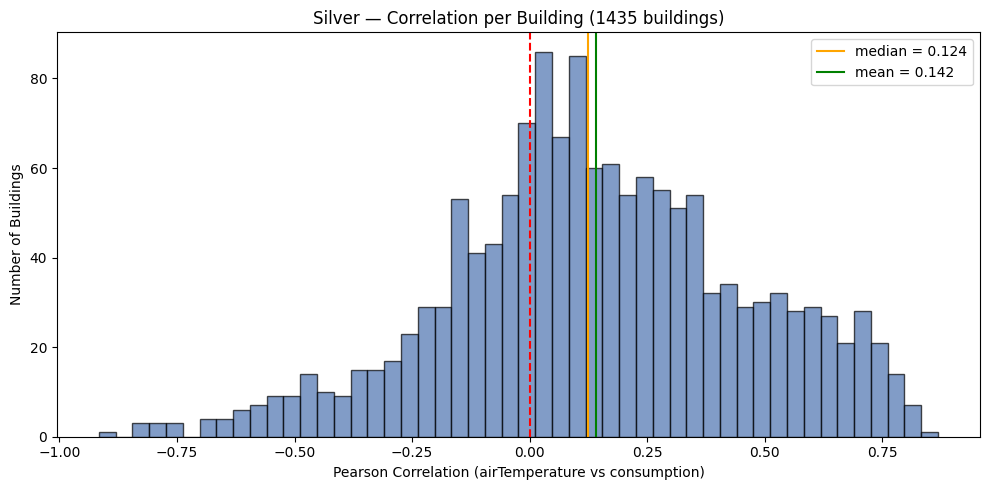


|corr| > 0.3:  550 (38.3%)
|corr| > 0.15: 908 (63.3%)
|corr| ≤ 0.15: 527 (36.7%)


In [20]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

silver = pl.read_parquet("D:/dmp-project/data2/processed/forecasting/silver/merged.parquet")

corr_by_building = (
    silver
    .filter(
        pl.col("airTemperature").is_not_null() & pl.col("consumption").is_not_null()
    )
    .group_by("building_id")
    .agg([
        pl.corr("airTemperature", "consumption", method="pearson").alias("correlation"),
        pl.col("consumption").mean().alias("mean_consumption"),
        pl.len().alias("n_rows"),
    ])
    .filter(pl.col("n_rows") > 100)
    .sort("correlation", descending=True)
)

corr_values = corr_by_building["correlation"].drop_nulls().to_numpy()

print(f"Buildings: {len(corr_values)}")
print(corr_by_building.select([
    pl.col("correlation").min().alias("min"),
    pl.col("correlation").quantile(0.25).alias("Q1"),
    pl.col("correlation").median().alias("median"),
    pl.col("correlation").mean().alias("mean"),
    pl.col("correlation").quantile(0.75).alias("Q3"),
    pl.col("correlation").max().alias("max"),
]))

print("\nTop 10 positive:")
print(corr_by_building.head(10))
print("\nTop 10 negative:")
print(corr_by_building.tail(10))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(corr_values, bins=50, edgecolor="black", alpha=0.7, color="#4C72B0")
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(x=np.median(corr_values), color="orange", linewidth=1.5,
           label=f"median = {np.median(corr_values):.3f}")
ax.axvline(x=np.mean(corr_values), color="green", linewidth=1.5,
           label=f"mean = {np.mean(corr_values):.3f}")
ax.set_xlabel("Pearson Correlation (airTemperature vs consumption)")
ax.set_ylabel("Number of Buildings")
ax.set_title(f"Silver — Correlation per Building ({len(corr_values)} buildings)")
ax.legend()
plt.tight_layout()
plt.savefig("correlation_silver_per_building.png", dpi=150)
plt.show()

strong = (np.abs(corr_values) > 0.3).sum()
moderate = (np.abs(corr_values) > 0.15).sum()
print(f"\n|corr| > 0.3:  {strong} ({strong/len(corr_values):.1%})")
print(f"|corr| > 0.15: {moderate} ({moderate/len(corr_values):.1%})")
print(f"|corr| ≤ 0.15: {len(corr_values)-moderate} ({(len(corr_values)-moderate)/len(corr_values):.1%})")